# MVP Model

In [1]:
# For data handling
import pandas as pd
import numpy as np

# To manage model loading and save paths
import os
import json
import joblib
from datetime import datetime

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier

In [2]:
# Creating a timestamp for saving model version number by date
timestamp = datetime.now().strftime("%Y_%m_%d")

# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/cleaned"
PROCESSED_PATH = "../../data/processed"
ML_PATH = "../../models/ml"
DL_PATH = "../../models/dl"
os.makedirs(ML_PATH, exist_ok=True)
os.makedirs(DL_PATH, exist_ok=True)

# Create a timestamped subdirectory inside DL and ML Path
versioned_dl_path = os.path.join(DL_PATH, f"MVP_{timestamp}")
os.makedirs(versioned_dl_path, exist_ok=True)

versioned_ml_path = os.path.join(ML_PATH, f"MVP_{timestamp}")
os.makedirs(versioned_ml_path, exist_ok=True)

In [3]:
# Loading the cleaned player data set
player_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

In [4]:
# Loading the mvp data set
mvp_df = pd.read_csv(f"{PROCESSED_PATH}/mvp_eda_cleaned.csv")

In [5]:
# Removing unnamed column
mvp_df.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
# Creating a dataframe to hold the Season column before merging 
selected_features = list(mvp_df.drop(columns=["is_MVP"]).columns)
reduced_with_season = player_df[selected_features + ["Season", "is_MVP"]].dropna()

After reviewing the data, we see there are 2 missing values in three separate columns. However the missing values in each column represents less than 1% of the data. Since neither column is the target column "is_MVP" we're going to drop them.

In [7]:
# Dropping missing data
mvp_df.dropna(inplace=True)

In [8]:
# Checking to see if indexes match before merging
mvp_df.index.equals(reduced_with_season.index)

True

In [9]:
# Merging processed dataset with modified dataset to retain Season column
mvp_df["Season"] = reduced_with_season["Season"]

In [10]:
mvp_df.head(5)

,VORP,FT,TOV,AST,DRB,PER,AST%,USG%,is_MVP,Season
0,7.5,9.2,3.3,2.8,6.3,26.2,13.5,32.0,0,2010
1,10.3,7.8,3.4,8.6,6.4,31.1,41.8,33.5,1,2010
2,2.9,7.4,3.0,3.2,4.4,22.2,15.9,33.4,0,2010
3,4.4,6.0,3.2,5.0,4.3,21.9,23.8,32.3,0,2010
4,7.9,6.9,3.3,6.5,3.5,28.0,36.4,34.9,0,2010


In [11]:
# Checking to make sure no null values remain
print(mvp_df.isnull().sum())

VORP      0
FT        0
TOV       0
AST       0
DRB       0
PER       0
AST%      0
USG%      0
is_MVP    0
Season    0
dtype: int64


In [12]:
# Assigning everything in one go to save memory and compute time
X_train, X_test, y_train, y_test = train_test_split(mvp_df.drop(columns=["is_MVP"]), mvp_df["is_MVP"], test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [15]:
# Model results
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1933    8]
 [   0    2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1941
           1       0.20      1.00      0.33         2

    accuracy                           1.00      1943
   macro avg       0.60      1.00      0.67      1943
weighted avg       1.00      1.00      1.00      1943



The initial model results shows us that the recall for MVPs = 1.0. This means all true MVPs are being captured. However, 8 non-MVPs were classified as MVPs using these methods. All non-MVPs were correctly predicted also.

## New approach : Handling data imbalance 
There is only 1 MVP in any given NBA season. We currently have 15 seasons worth of data, meaning amongst the 1000s of rows of data existing in this data set, only 15 rows will contain an MVP winner. So, to account for this we will change the approach and have the model try to find the MVP for a given season, separating the parameters on a per season basis.

In [16]:
mvp_normalized = mvp_df.copy()
features = mvp_normalized.drop(columns=["is_MVP", "Season"]).columns

for season in mvp_df["Season"].unique():
    season_mask = mvp_df["Season"] == season
    scaler = MinMaxScaler()
    mvp_normalized.loc[season_mask, features] = scaler.fit_transform(mvp_df.loc[season_mask, features])

In [17]:
# Assigning everything in one go to save memory and compute time
X_train, X_test, y_train, y_test = train_test_split(mvp_df.drop(columns=["is_MVP", "Season"]), mvp_df["is_MVP"], test_size=0.2, random_state=42)

In [18]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
# Creating a MVP Score column using the model 
X = mvp_normalized.drop(columns=["is_MVP", "Season"])
mvp_normalized["MVP_Score"] = model.predict_proba(X)[:,1]

In [20]:
predicted_mvps = mvp_normalized.loc[mvp_normalized.groupby("Season")["MVP_Score"].idxmax()]

In [21]:
# Evaluations
actual_mvps = mvp_normalized[mvp_normalized["is_MVP"] ==1]
correct_predictions = (predicted_mvps["is_MVP"] ==1).sum()

print(f"Correct MVP predictions: {correct_predictions} / {actual_mvps.shape[0]}")

Correct MVP predictions: 9 / 15


## Next we're going to test other models like Random Forest Classifier and XGBoost

In [22]:
# Random Forest 
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [23]:
mvp_normalized_rf = mvp_normalized.copy()

In [24]:
mvp_normalized_rf.drop(columns=["MVP_Score"], inplace=True)

In [25]:
# Creating a MVP Score column using the model 
X_rf = mvp_normalized_rf.drop(columns=["is_MVP", "Season"])
mvp_normalized_rf["MVP_Score"] = rf.predict_proba(X_rf)[:,1]

In [26]:
predicted_mvps_rf = mvp_normalized_rf.loc[mvp_normalized_rf.groupby("Season")["MVP_Score"].idxmax()]

In [27]:
# Evaluations
actual_mvps_rf = mvp_normalized_rf[mvp_normalized_rf["is_MVP"] ==1]
correct_predictions_rf = (predicted_mvps_rf["is_MVP"] ==1).sum()

print(f"Correct MVP predictions: {correct_predictions_rf} / {actual_mvps_rf.shape[0]}")

Correct MVP predictions: 5 / 15


In [28]:
# XGBoost
xgb = XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [29]:
mvp_normalized_xgb = mvp_normalized.copy()

In [30]:
mvp_normalized_xgb.drop(columns=["MVP_Score"], inplace=True)

In [31]:
# Creating a MVP Score column using the model 
X_xgb = mvp_normalized_xgb.drop(columns=["is_MVP", "Season"])
mvp_normalized_xgb["MVP_Score"] = xgb.predict_proba(X_xgb)[:,1]

In [32]:
predicted_mvps_xgb = mvp_normalized_xgb.loc[mvp_normalized_xgb.groupby("Season")["MVP_Score"].idxmax()]

In [33]:
# Evaluations
actual_mvps_xgb = mvp_normalized_xgb[mvp_normalized_xgb["is_MVP"] ==1]
correct_predictions_xgb = (predicted_mvps_xgb["is_MVP"] ==1).sum()

print(f"Correct MVP predictions: {correct_predictions_xgb} / {actual_mvps_xgb.shape[0]}")

Correct MVP predictions: 5 / 15


The results of the ML models are as follows:
Logistic Regression: 9/15
Random Forest Classifier: 5/15
XGBoost: 5/15

The results of the ML models leave more to be desired, even after tuning and carefully selecting features the models fail to reach at least 80% accuracy. 

## Next phase: Deep Learning

In [34]:
# Creating features and target for Torch Tensor Model
features = mvp_df.drop(columns=["is_MVP", "Season"])
target = mvp_df["is_MVP"]

In [35]:
# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [36]:
# Convert to tensors
X_tensor = torch.tensor(features_scaled, dtype=torch.float32)
y_tensor = torch.tensor(target.values, dtype=torch.float32).unsqueeze(1)

In [37]:
# Train/test split
X_train_nm, X_test_nm, y_train_nm, y_test_nm = train_test_split(X_tensor, y_tensor, test_size=0.2, stratify=y_tensor, random_state=42)

In [38]:
# Wrap in datasets
train_ds = TensorDataset(X_train_nm, y_train_nm)
test_ds = TensorDataset(X_test_nm, y_test_nm)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [39]:
class MVPNet(nn.Module):
    def __init__(self, input_dim):
        super(MVPNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [40]:
model_nn = MVPNet(X_train_nm.shape[1])

In [41]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
train_losses = []

epochs = 100
for epoch in range(epochs):
    model_nn.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_nn(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

Epoch 0, Loss: 25.7312
Epoch 10, Loss: 0.6172
Epoch 20, Loss: 0.4131
Epoch 30, Loss: 0.3150
Epoch 40, Loss: 0.3571
Epoch 50, Loss: 0.3193
Epoch 60, Loss: 0.2304
Epoch 70, Loss: 0.2085
Epoch 80, Loss: 0.3270
Epoch 90, Loss: 0.2437


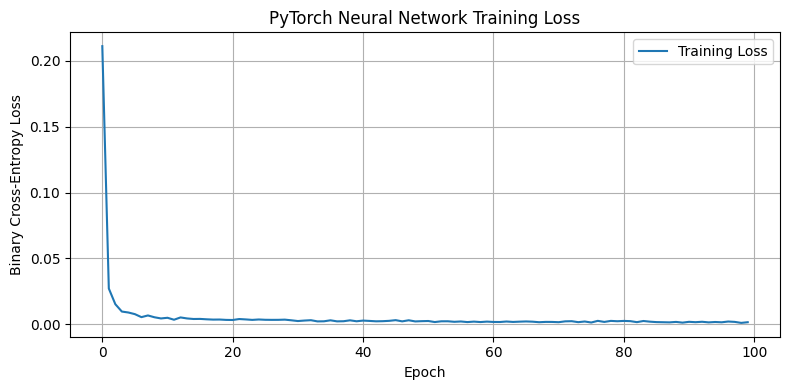

In [42]:
# Visualizing the results of training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.title('PyTorch Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
# Put model in eval mode
model_nn.eval()
with torch.no_grad():
    full_X = torch.tensor(scaler.transform(features), dtype=torch.float32)
    mvp_scores = model_nn(full_X).squeeze().numpy()

mvp_df["MVP_Score"] = mvp_scores
predicted_mvps = mvp_df.loc[mvp_df.groupby("Season")["MVP_Score"].idxmax()]
actual_mvps = mvp_df[mvp_df["is_MVP"] == 1]
correct_preds = (predicted_mvps["is_MVP"] == 1).sum()

print(f"Correct MVP predictions (PyTorch NN): {correct_preds} / {actual_mvps.shape[0]}")


Correct MVP predictions (PyTorch NN): 12 / 15


The PyTorch NN obtained a score of 11/15 (73%). This is the best model so far but still not good enough. We need an accuracy score of at least 90% to show confidence in the prediction capabilities of the model.

PyTorch appears to be the better model choice for this dataset. Given that, we're going to expand the model by creating a deeper architecture, using LeakyReLu activations, regularizing dropout and handling the class imablance better.

In [44]:
class MVPNET(nn.Module):
    """
    A feedforward neural network for predicting NBA MVP likelihood based on player stats.

    Args:
        input_dim (int): Number of input features
    """
    def __init__(self, input_dim):
        """
        Initializes the MVPNet model with a series of fully connected layers,
        LeakyReLu activations, and dropout regularization.

        Args:
            input_dim (int): Number of input features
        """
        super(MVPNET, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), # The expanding architecture
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            
            nn.Linear(16, 1)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the network

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)
            
        Returns:
            torch.Tensor: Output tensor with shape (batch_size, 1), representing MVP prediction scores.
        """
        
        return self.network(x)
        

In [45]:
model_net = MVPNET(X_train_nm.shape[1])

# Class imbalance weighting
pos_weight_val = torch.tensor([len(y_train_nm) / y_train_nm.sum()])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)

# Optimizer with L2 Regularization (weight_decay)
optimizer_net = torch.optim.Adam(model_net.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler_net = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_net, mode="min", patience=3, factor=0.5)

In [46]:
# Model training
train_losses_net = []
epochs = 200

for epoch in range(epochs):
    model_net.train()
    total_loss = 0
    
    for xb, yb, in train_loader:
        optimizer_net.zero_grad()
        preds = model_net(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer_net.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses_net.append(avg_loss)
    scheduler_net.step(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")
        

Epoch 0, Loss: 1.3251
Epoch 10, Loss: 0.0478
Epoch 20, Loss: 0.0453
Epoch 30, Loss: 0.0466
Epoch 40, Loss: 0.0580
Epoch 50, Loss: 0.0419
Epoch 60, Loss: 0.0654
Epoch 70, Loss: 0.0599
Epoch 80, Loss: 0.0511
Epoch 90, Loss: 0.0449
Epoch 100, Loss: 0.0664
Epoch 110, Loss: 0.0505
Epoch 120, Loss: 0.0588
Epoch 130, Loss: 0.0438
Epoch 140, Loss: 0.0552
Epoch 150, Loss: 0.0455
Epoch 160, Loss: 0.0439
Epoch 170, Loss: 0.0485
Epoch 180, Loss: 0.0503
Epoch 190, Loss: 0.0457


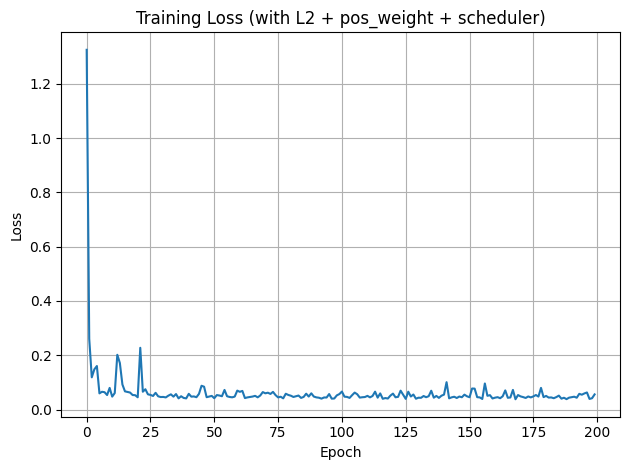

In [47]:
# Visualizing the loss
plt.plot(train_losses_net)
plt.title("Training Loss (with L2 + pos_weight + scheduler)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# Run model and make predictions
model_net.eval()
with torch.no_grad():
    logits = model_net(torch.tensor(scaler.transform(features), dtype=torch.float32))
    probs = torch.sigmoid(logits).squeeze().numpy()

mvp_df["MVP_Score"] = probs
predicted_mvps_net = mvp_df.loc[mvp_df.groupby("Season")["MVP_Score"].idxmax()]
actual_mvps_net = mvp_df[mvp_df["is_MVP"] == 1]
correct_preds_net = (predicted_mvps_net["is_MVP"] == 1).sum()

print(f"Correct MVP Predictions (Tuned NN): {correct_preds_net} / {actual_mvps_net.shape[0]}")

Correct MVP Predictions (Tuned NN): 11 / 15


The results here are the same as the prior model despite fine tuning. Now we're going to try and upgrade this model even more by adding a learning rate decay and bacthnorm after every dense layer

In [49]:
class MVPNet(nn.Module):
    def __init__(self, input_dim):
        super(MVPNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),

            nn.Linear(16, 1)  
        )

    def forward(self, x):
        return self.network(x)


In [50]:
# Early stopping
best_loss = float("inf")
patience = 5
wait = 0
best_model_state = None

In [51]:
train_losses_es = []

for epoch in range(100):
    model_net.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer_net.zero_grad()
        preds = model_net(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer_net.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses_es.append(avg_loss)
    scheduler_net.step(avg_loss)

    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss:
        best_loss = avg_loss
        wait = 0
        best_model_state = model_net.state_dict()
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered")
            break

# Load best weights
if best_model_state:
    model_net.load_state_dict(best_model_state)


Epoch 0, Loss: 0.0433
Epoch 1, Loss: 0.0574
Epoch 2, Loss: 0.0453
Epoch 3, Loss: 0.0354
Epoch 4, Loss: 0.0494
Epoch 5, Loss: 0.0447
Epoch 6, Loss: 0.0407
Epoch 7, Loss: 0.0465
Epoch 8, Loss: 0.0413
Early stopping triggered


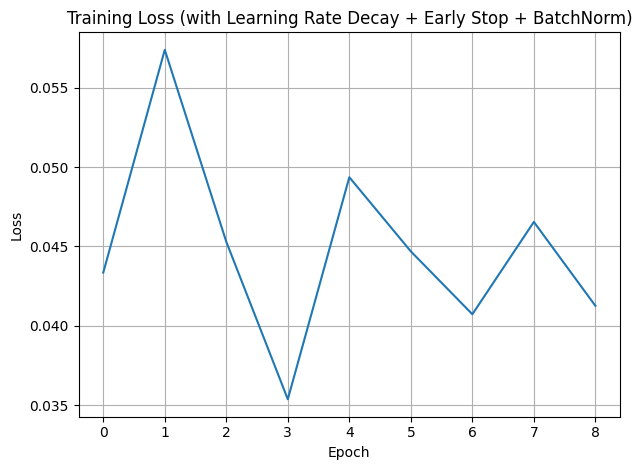

In [52]:
# Visualizing the loss
plt.plot(train_losses_es)
plt.title("Training Loss (with Learning Rate Decay + Early Stop + BatchNorm)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
mvp_df_es = mvp_df.copy()

In [54]:
mvp_df_es.drop(columns=["MVP_Score"], inplace=True)

In [55]:
# Run model and make predictions
model_net.eval()
with torch.no_grad():
    logits = model_net(torch.tensor(scaler.transform(features), dtype=torch.float32))
    probs = torch.sigmoid(logits).squeeze().numpy()

mvp_df_es["MVP_Score"] = probs
predicted_mvps_es = mvp_df_es.loc[mvp_df_es.groupby("Season")["MVP_Score"].idxmax()]
actual_mvps_es = mvp_df_es[mvp_df_es["is_MVP"] == 1]
correct_preds_es = (predicted_mvps_es["is_MVP"] == 1).sum()

print(f"Correct MVP Predictions (Tuned w/ES): {correct_preds_es} / {actual_mvps_es.shape[0]}")

Correct MVP Predictions (Tuned w/ES): 11 / 15


The final approach will be to use TabNet.

In [56]:
mvp_df_tab = mvp_df.copy()
mvp_df_tab.drop(columns=["MVP_Score"], inplace=True)

In [57]:
X_tab = mvp_df_tab.drop(columns=["is_MVP", "Season"]).values
y_tab = mvp_df_tab["is_MVP"].values

scaler = StandardScaler()
X_scaled_tab = scaler.fit_transform(X_tab)

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(X_scaled_tab, y_tab, test_size=0.2, stratify=y_tab, random_state=42)

In [58]:
tabnet_model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',  # or 'entmax'
    verbose=10,
    seed=42
)

c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [59]:
tabnet_model.fit(
    X_train=X_train_tab, y_train=y_train_tab,
    eval_set=[(X_train_tab, y_train_tab), (X_test_tab, y_test_tab)],
    eval_name=['train', 'valid'],
    eval_metric=['logloss'],
    max_epochs=200,
    patience=10,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

epoch 0  | loss: 0.31386 | train_logloss: 0.31016 | valid_logloss: 0.31493 |  0:00:00s
epoch 10 | loss: 0.01438 | train_logloss: 0.01314 | valid_logloss: 0.01254 |  0:00:06s
epoch 20 | loss: 0.00643 | train_logloss: 0.0056  | valid_logloss: 0.00561 |  0:00:12s
epoch 30 | loss: 0.00566 | train_logloss: 0.0041  | valid_logloss: 0.00526 |  0:00:18s
epoch 40 | loss: 0.00528 | train_logloss: 0.00531 | valid_logloss: 0.00471 |  0:00:25s
epoch 50 | loss: 0.00564 | train_logloss: 0.00354 | valid_logloss: 0.0055  |  0:00:31s

Early stopping occurred at epoch 51 with best_epoch = 41 and best_valid_logloss = 0.00392


c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [60]:
# Predict probabilities for the full dataset
X_all = scaler.transform(mvp_df_tab.drop(columns=["is_MVP", "Season"]).values)
probs = tabnet_model.predict_proba(X_all)[:, 1]
mvp_df_tab["MVP_Score"] = probs

# Get top scorer per season
predicted_mvps_tab = mvp_df_tab.loc[mvp_df_tab.groupby("Season")["MVP_Score"].idxmax()]
actual_mvps_tab = mvp_df_tab[mvp_df_tab["is_MVP"] == 1]
correct_preds_tab = (predicted_mvps_tab["is_MVP"] == 1).sum()

print(f"Correct MVP Predictions (TabNet): {correct_preds_tab} / {actual_mvps_tab.shape[0]}")


Correct MVP Predictions (TabNet): 10 / 15


In [61]:
feature_list = [
    "VORP", "FT", "TOV", "AST",
    "DRB", "PER", "AST%", "USG%"
]

Now that the results are acceptable, we can save the best ML and DL models.

In [62]:
# Deep Learning Model Save
model_path = os.path.join(versioned_dl_path, "MVP_model_weights.pth")
torch.save(model_net.state_dict(), model_path)

# Deep Learning Scaler save
scaler_path = os.path.join(versioned_dl_path, "MVP_scaler.pkl")
joblib.dump(scaler, scaler_path)

# Features and metadata save
feature_list_path = os.path.join(versioned_dl_path, "MVP_feature_list.json")
metadata = {
    "timestamp": timestamp,
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 7.0,
    "notes" : "Deep learning DPOY model trained on all-season data"
}

# Feature list save

with open(feature_list_path, "w") as f:
    json.dump(metadata, f, indent=4)


In [63]:
# Machine Learning Model save
ml_model_path = os.path.join(versioned_ml_path, "MVP_ml_model.pkl")
joblib.dump(model, ml_model_path)

# Machine Learning Scaler save
ml_scaler_path = os.path.join(versioned_ml_path, "MVP__ml_scaler.pkl")
joblib.dump(scaler, ml_scaler_path)

# Metadata save

ml_metadata = {
    "timestamp": timestamp,
    "model_type" : str(type(model)).split("'")[1],
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 0.5,
    "notes" : "Best ML Model for DPOY prediction"
}

ml_metadata_path = os.path.join(versioned_ml_path, "MVP_ml_feature_list.json")
with open(ml_metadata_path, "w") as f:
    json.dump(ml_metadata, f, indent=4)
